In [14]:
from __future__ import annotations

from pathlib import Path
import json
from datetime import datetime ,timezone

import numpy as np
import pandas as pd

import geopandas as gpd
import matplotlib .pyplot as plt


In [15]:
project_root =Path ('/Users/aaronspaulding/Documents/PycharmProjects/research_spring_2026')
data_cache_dir =project_root /'data_cache'

static_input_path =data_cache_dir /'aggregated_static_variables.feather'
h3_cells_path =Path ('/Users/aaronspaulding/data/weather_db_hurricane_regions/h3_cells_cached.feather')
fips_fallback_path =data_cache_dir /'static_variables_fips_and_census.feather'

output_features_path =data_cache_dir /'static_region_features.feather'
output_meta_path =data_cache_dir /'static_region_features_metadata.json'

output_features_path .parent .mkdir (parents =True ,exist_ok =True )

print ('static_input_path:',static_input_path )
print ('h3_cells_path:',h3_cells_path )
print ('fips_fallback_path:',fips_fallback_path )
print ('output_features_path:',output_features_path )


static_input_path: /Users/aaronspaulding/Documents/PycharmProjects/research_spring_2026/data_cache/aggregated_static_variables.feather
h3_cells_path: /Users/aaronspaulding/data/weather_db_hurricane_regions/h3_cells_cached.feather
fips_fallback_path: /Users/aaronspaulding/Documents/PycharmProjects/research_spring_2026/data_cache/static_variables_fips_and_census.feather
output_features_path: /Users/aaronspaulding/Documents/PycharmProjects/research_spring_2026/data_cache/static_region_features.feather


In [16]:
static_index =pd .read_feather (static_input_path ,columns =['index'])

h3_state =None

try :
    h3_state =pd .read_feather (h3_cells_path ,columns =['index','STATEFP'])
except Exception :
    h3_state =None

if h3_state is None or 'STATEFP'not in h3_state .columns :
    if not fips_fallback_path .exists ():
        raise RuntimeError (
        'Could not load STATEFP from h3_cells_cached.feather and fallback file is missing: '
        f'{fips_fallback_path}'
        )
    h3_state =pd .read_feather (fips_fallback_path ,columns =['index','STATEFP'])

h3_state =h3_state .dropna (subset =['index','STATEFP']).drop_duplicates (subset =['index']).reset_index (drop =True )
region_df =static_index .merge (h3_state ,on ='index',how ='left',validate ='many_to_one')

if region_df ['STATEFP'].isna ().any ():
    missing_count =int (region_df ['STATEFP'].isna ().sum ())
    raise ValueError (f'Missing STATEFP for {missing_count} cells after merge.')

region_df ['STATEFP']=region_df ['STATEFP'].astype (str ).str .zfill (2 )

print ('num_cells:',region_df .shape [0 ])
print ('num_states_present:',region_df ['STATEFP'].nunique ())


num_cells: 3571572
num_states_present: 23


In [17]:
state_categories =sorted (region_df ['STATEFP'].unique ().tolist ())
state_to_idx ={statefp :i for i ,statefp in enumerate (state_categories )}

region_df ['state_idx']=region_df ['STATEFP'].map (state_to_idx ).astype (np .int16 )

print ('state_categories:',len (state_categories ))
print ('example mapping:',dict (list (state_to_idx .items ())[:10 ]))

def state_one_hot_from_idx (state_idx :np .ndarray ,num_states :int ,dtype =np .float32 )->np .ndarray :

    out =np .zeros ((state_idx .shape [0 ],num_states ),dtype =dtype )
    out [np .arange (state_idx .shape [0 ]),state_idx ]=1
    return out


state_categories: 23
example mapping: {'01': 0, '06': 1, '09': 2, '10': 3, '11': 4, '12': 5, '13': 6, '22': 7, '23': 8, '24': 9}


In [37]:
NEW_ENGLAND ={'09','23','25','33','44','50','36'}
GULF ={'01','12','22','28','48'}
EASTERN_COAST ={
'10','11','13','24','34','37','45','51','42'
}

region_df ['region_new_england']=region_df ['STATEFP'].isin (NEW_ENGLAND ).astype (np .int8 )
region_df ['region_gulf']=region_df ['STATEFP'].isin (GULF ).astype (np .int8 )
region_df ['region_eastern_coast']=region_df ['STATEFP'].isin (EASTERN_COAST ).astype (np .int8 )

macro_region =np .full (region_df .shape [0 ],'other',dtype =object )
macro_region [region_df ['region_eastern_coast'].to_numpy (dtype =bool )]='eastern_coast'
macro_region [region_df ['region_gulf'].to_numpy (dtype =bool )]='gulf'
macro_region [region_df ['region_new_england'].to_numpy (dtype =bool )]='new_england'

region_df ['macro_region_exclusive']=macro_region

macro_categories =['other','eastern_coast','gulf','new_england']
macro_to_idx ={name :i for i ,name in enumerate (macro_categories )}
region_df ['macro_region_exclusive_idx']=region_df ['macro_region_exclusive'].map (macro_to_idx ).astype (np .int8 )

region_df ['macro_region_exclusive'].value_counts (dropna =False )


macro_region_exclusive
gulf             1619700
eastern_coast     964494
other             565256
new_england       422122
Name: count, dtype: int64

In [38]:
print ('Fuzzy boundaries: disabled')


Fuzzy boundaries: disabled


In [39]:
columns_to_save =[
'index',
'STATEFP',
'state_idx',
'region_new_england',
'region_gulf',
'region_eastern_coast',
'macro_region_exclusive',
'macro_region_exclusive_idx',
]

region_features =region_df [columns_to_save ].copy ()
region_features .to_feather (output_features_path )

meta ={
'created_utc':datetime .now (timezone .utc ).isoformat (),
'source_static':str (static_input_path ),
'source_h3_cells':str (h3_cells_path ),
'num_rows':int (region_features .shape [0 ]),
'state_to_idx':state_to_idx ,
'macro_to_idx':macro_to_idx ,
'new_england_statefp':sorted (NEW_ENGLAND ),
'gulf_statefp':sorted (GULF ),
'eastern_coast_statefp':sorted (EASTERN_COAST ),
}
output_meta_path .write_text (json .dumps (meta ,indent =2 ))

print ('saved:',output_features_path )
print ('saved:',output_meta_path )
print ('shape:',region_features .shape )
region_features .head ()


saved: /Users/aaronspaulding/Documents/PycharmProjects/research_spring_2026/data_cache/static_region_features.feather
saved: /Users/aaronspaulding/Documents/PycharmProjects/research_spring_2026/data_cache/static_region_features_metadata.json
shape: (3571572, 8)


,index,STATEFP,state_idx,region_new_england,region_gulf,region_eastern_coast,macro_region_exclusive,macro_region_exclusive_idx
0,8826490001fffff,01,0,0,1,0,gulf,2
1,8826490003fffff,01,0,0,1,0,gulf,2
2,8826490005fffff,01,0,0,1,0,gulf,2
3,8826490007fffff,01,0,0,1,0,gulf,2
4,8826490009fffff,01,0,0,1,0,gulf,2


In [40]:
num_cells =int (region_df .shape [0 ])
num_states =int (len (state_categories ))

bytes_state_one_hot_f32 =num_cells *num_states *4
bytes_state_idx_i16 =num_cells *2
bytes_macro_idx_i8 =num_cells *1
bytes_hard_3x_i8 =num_cells *3 *1

print ('num_cells:',num_cells )
print ('num_states:',num_states )
print ('')
print ('state one-hot (float32) MB:',round (bytes_state_one_hot_f32 /1e6 ,2 ))
print ('state_idx (int16) MB:',round (bytes_state_idx_i16 /1e6 ,2 ))
print ('macro_region_idx (int8) MB:',round (bytes_macro_idx_i8 /1e6 ,2 ))
print ('hard 3-region flags (int8) MB:',round (bytes_hard_3x_i8 /1e6 ,2 ))


num_cells: 3571572
num_states: 23

state one-hot (float32) MB: 328.58
state_idx (int16) MB: 7.14
macro_region_idx (int8) MB: 3.57
hard 3-region flags (int8) MB: 10.71


/var/folders/ch/9_p_rc990bzgkvhgv_f_0kr00000gn/T/ipykernel_71167/4075533590.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plot_points['geometry'] = plot_points.geometry.centroid


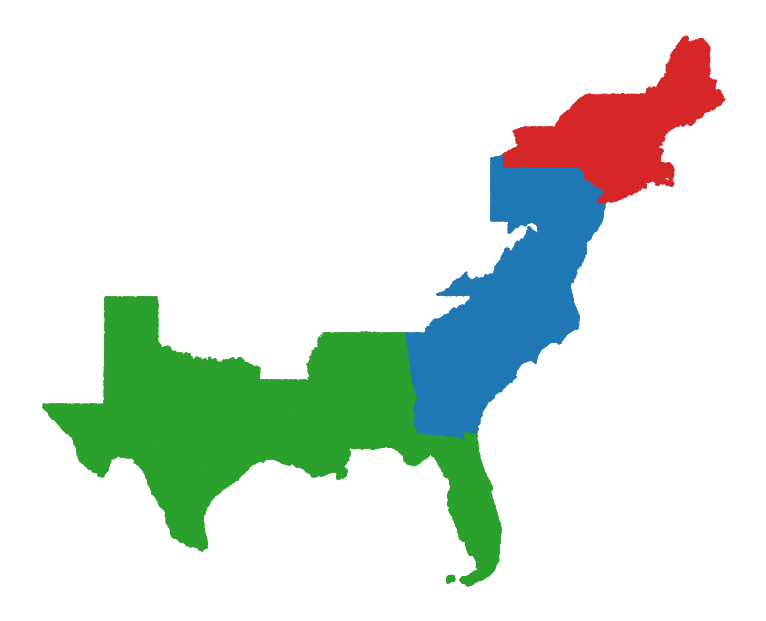

In [43]:
plot_sample_size =250_000
plot_random_state =42

plot_columns =[
'index',
'STATEFP',
'region_new_england',
'region_gulf',
'region_eastern_coast',
'macro_region_exclusive',
]

plot_features =region_features [plot_columns ].copy ()

h3_geometry =gpd .read_feather (h3_cells_path )
h3_geometry =h3_geometry [['index','geometry']].drop_duplicates (subset =['index']).reset_index (drop =True )

plot_gdf =h3_geometry .merge (plot_features ,on ='index',how ='inner',validate ='one_to_one')

plot_gdf =plot_gdf [~plot_gdf ['STATEFP'].astype (str ).str .zfill (2 ).isin (['06','72'])].copy ()

if plot_gdf .shape [0 ]>plot_sample_size :
    plot_gdf =plot_gdf .sample (n =plot_sample_size ,random_state =plot_random_state ).reset_index (drop =True )

plot_points =plot_gdf .copy ()
plot_points ['geometry']=plot_points .geometry .centroid

macro_palette ={
'other':'#9aa0a6',
'eastern_coast':'#1f77b4',
'gulf':'#2ca02c',
'new_england':'#d62728',
}

fig ,ax =plt .subplots (figsize =(10 ,7 ),dpi =90 )
for region_name ,color in macro_palette .items ():
    idx =plot_points ['macro_region_exclusive']==region_name
    if int (idx .sum ())==0 :
        continue
    plot_points .loc [idx ].plot (
    ax =ax ,
    color =color ,
    markersize =0.7 ,
    label =f"{region_name} (n={int(idx.sum())})",
    )

ax .set_axis_off ()

plt .tight_layout ()
plt .show ()


In [44]:
state_name_map ={
'01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT','10':'DE',
'11':'DC','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL','18':'IN','19':'IA',
'20':'KS','21':'KY','22':'LA','23':'ME','24':'MD','25':'MA','26':'MI','27':'MN',
'28':'MS','29':'MO','30':'MT','31':'NE','32':'NV','33':'NH','34':'NJ','35':'NM',
'36':'NY','37':'NC','38':'ND','39':'OH','40':'OK','41':'OR','42':'PA','44':'RI',
'45':'SC','46':'SD','47':'TN','48':'TX','49':'UT','50':'VT','51':'VA','53':'WA',
'54':'WV','55':'WI','56':'WY','60':'AS','66':'GU','69':'MP','72':'PR','78':'VI',
}

state_summary =(
region_features .assign (
STATEFP =region_features ['STATEFP'].astype (str ).str .zfill (2 ),
state_abbr =lambda d :d ['STATEFP'].map (state_name_map ).fillna (d ['STATEFP']),
)
.groupby (['STATEFP','state_abbr'],as_index =False )
.size ()
.rename (columns ={'size':'num_cells'})
.sort_values ('num_cells',ascending =False )
.reset_index (drop =True )
)

print ('num_states:',state_summary .shape [0 ])
state_summary


num_states: 23


,STATEFP,state_abbr,num_cells
0,48,TX,827631
1,06,CA,539134
2,12,FL,269716
3,13,GA,223168
4,37,NC,209901
5,01,AL,185842
6,36,NY,183175
7,22,LA,171725
8,28,MS,164786
9,42,PA,160141


/var/folders/ch/9_p_rc990bzgkvhgv_f_0kr00000gn/T/ipykernel_71167/971266207.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  state_points['geometry'] = state_points.geometry.centroid


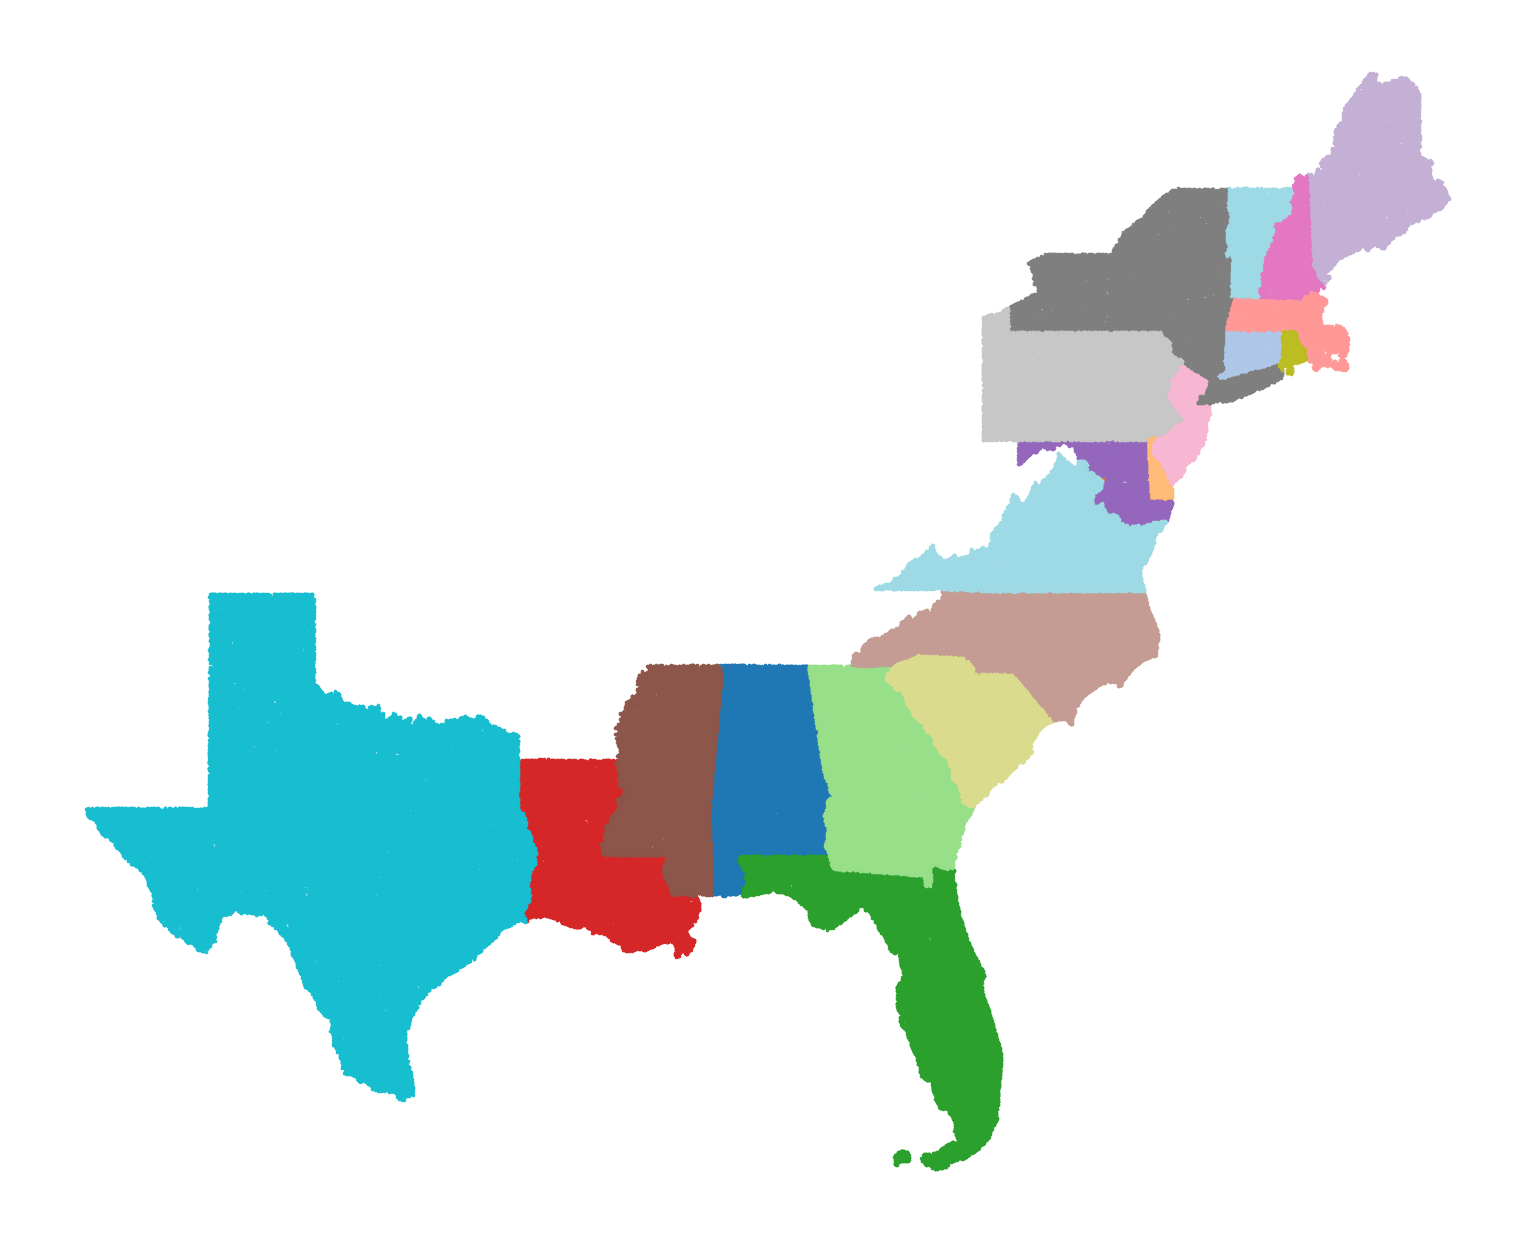

In [49]:
state_plot_features =region_features [['index','STATEFP']].copy ()

h3_geometry_state =gpd .read_feather (h3_cells_path )
h3_geometry_state =h3_geometry_state [['index','geometry']].drop_duplicates (subset =['index']).reset_index (drop =True )

state_gdf =h3_geometry_state .merge (state_plot_features ,on ='index',how ='inner',validate ='one_to_one')
state_gdf ['STATEFP']=state_gdf ['STATEFP'].astype (str ).str .zfill (2 )
state_gdf =state_gdf [~state_gdf ['STATEFP'].isin (['06','72'])].copy ()

state_sample_size =300_000
if state_gdf .shape [0 ]>state_sample_size :
    state_gdf =state_gdf .sample (n =state_sample_size ,random_state =42 ).reset_index (drop =True )

state_points =state_gdf .copy ()
state_points ['geometry']=state_points .geometry .centroid
state_points ['state_abbr']=state_points ['STATEFP'].map (state_name_map ).fillna (state_points ['STATEFP'])

unique_states =sorted (state_points ['state_abbr'].unique ().tolist ())
state_cmap =plt .get_cmap ('tab20',len (unique_states ))
state_palette ={state :state_cmap (i )for i ,state in enumerate (unique_states )}

fig ,ax =plt .subplots (figsize =(11 ,7 ),dpi =180 )
for state in unique_states :
    idx =state_points ['state_abbr']==state
    if int (idx .sum ())==0 :
        continue
    state_points .loc [idx ].plot (
    ax =ax ,
    color =state_palette [state ],
    markersize =0.2 ,
    label =f"{state} (n={int(idx.sum())})",
    )

ax .set_axis_off ()

plt .tight_layout ()
plt .show ()


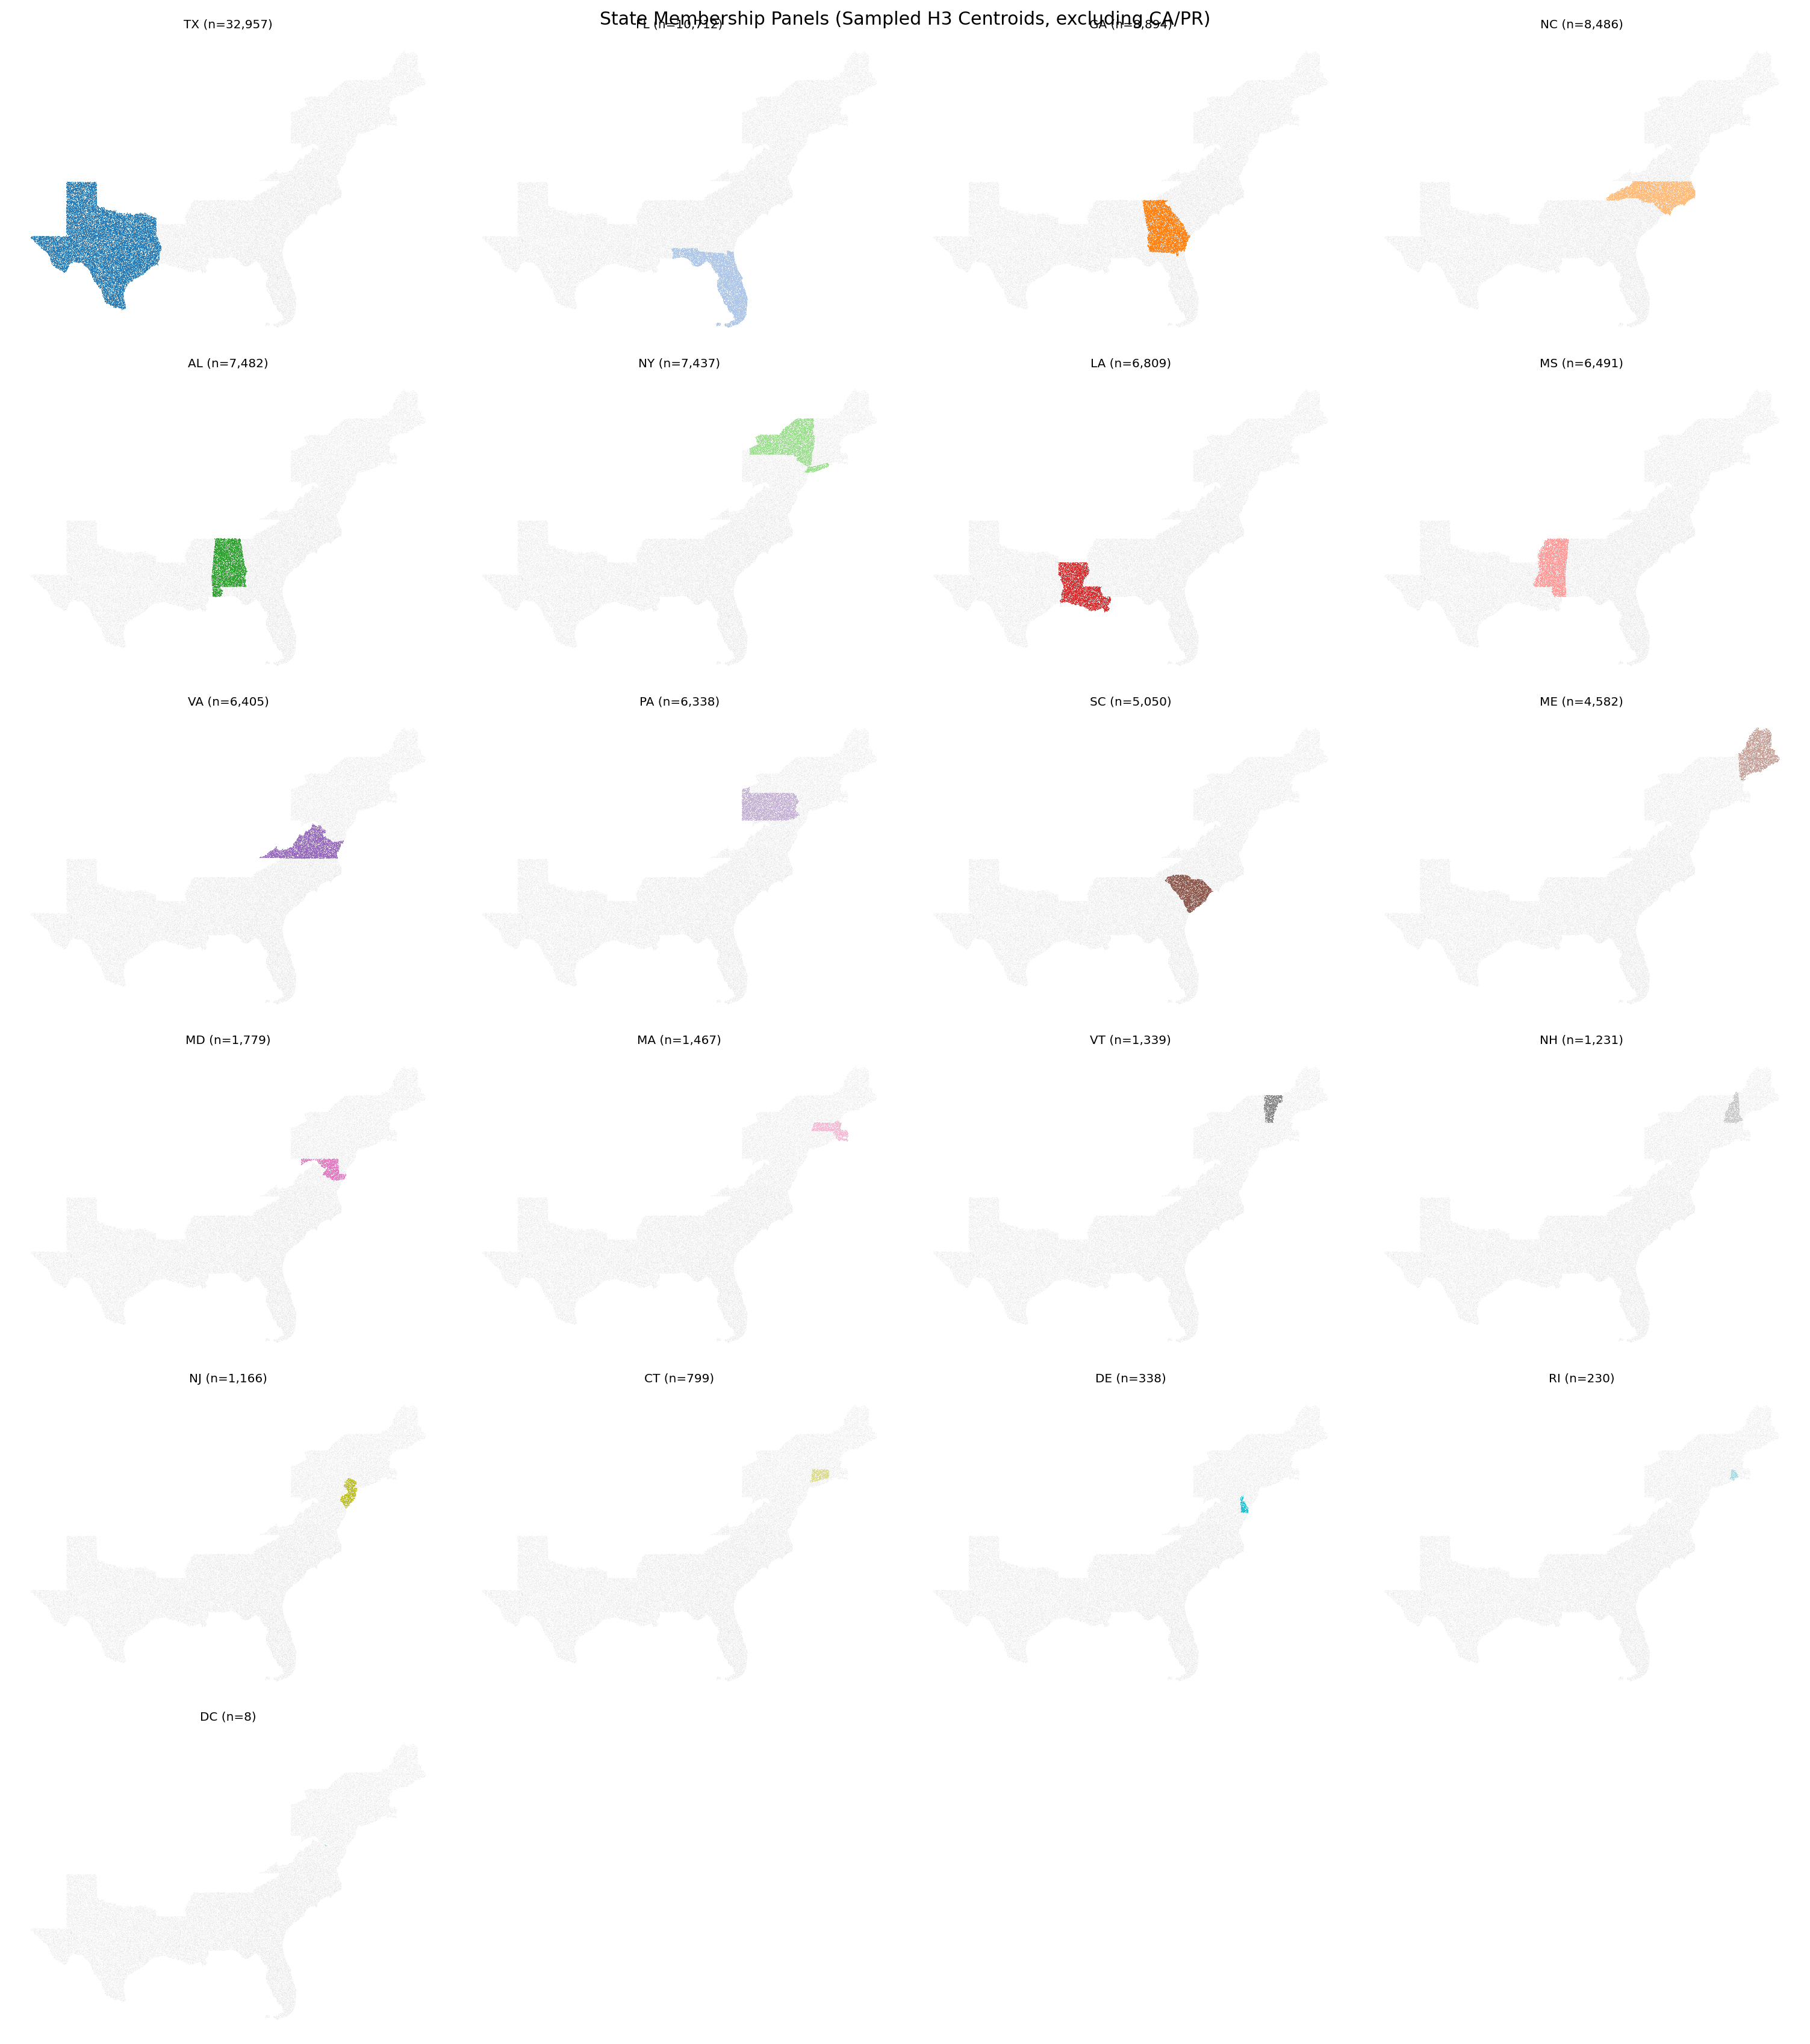

In [46]:
if 'state_points'not in globals ():
    raise RuntimeError ('Run the previous state plot cell first to create `state_points`.')

facet_points =state_points .copy ()
facet_sample_size =120_000
if facet_points .shape [0 ]>facet_sample_size :
    facet_points =facet_points .sample (n =facet_sample_size ,random_state =123 ).reset_index (drop =True )

facet_points ['x']=facet_points .geometry .x
facet_points ['y']=facet_points .geometry .y

state_order =(
facet_points ['state_abbr']
.value_counts ()
.index
.tolist ()
)

n_states =len (state_order )
ncols =4
nrows =int (np .ceil (n_states /ncols ))

facet_cmap =plt .get_cmap ('tab20',max (n_states ,1 ))
facet_palette ={state :facet_cmap (i )for i ,state in enumerate (state_order )}

fig ,axes =plt .subplots (nrows ,ncols ,figsize =(4.2 *ncols ,3.2 *nrows ),dpi =180 )
axes =np .atleast_1d (axes ).ravel ()

x_all =facet_points ['x'].to_numpy ()
y_all =facet_points ['y'].to_numpy ()
state_arr =facet_points ['state_abbr'].to_numpy ()

for i ,state in enumerate (state_order ):
    ax =axes [i ]

    ax .scatter (x_all ,y_all ,s =0.08 ,c ='#d0d0d0',alpha =0.16 ,linewidths =0 )
    idx =state_arr ==state
    ax .scatter (x_all [idx ],y_all [idx ],s =0.20 ,c =[facet_palette [state ]],alpha =0.9 ,linewidths =0 )

    ax .set_title (f"{state} (n={int(idx.sum()):,})",fontsize =8 )
    ax .set_axis_off ()

for j in range (n_states ,len (axes )):
    axes [j ].set_visible (False )

plt .tight_layout ()
plt .show ()


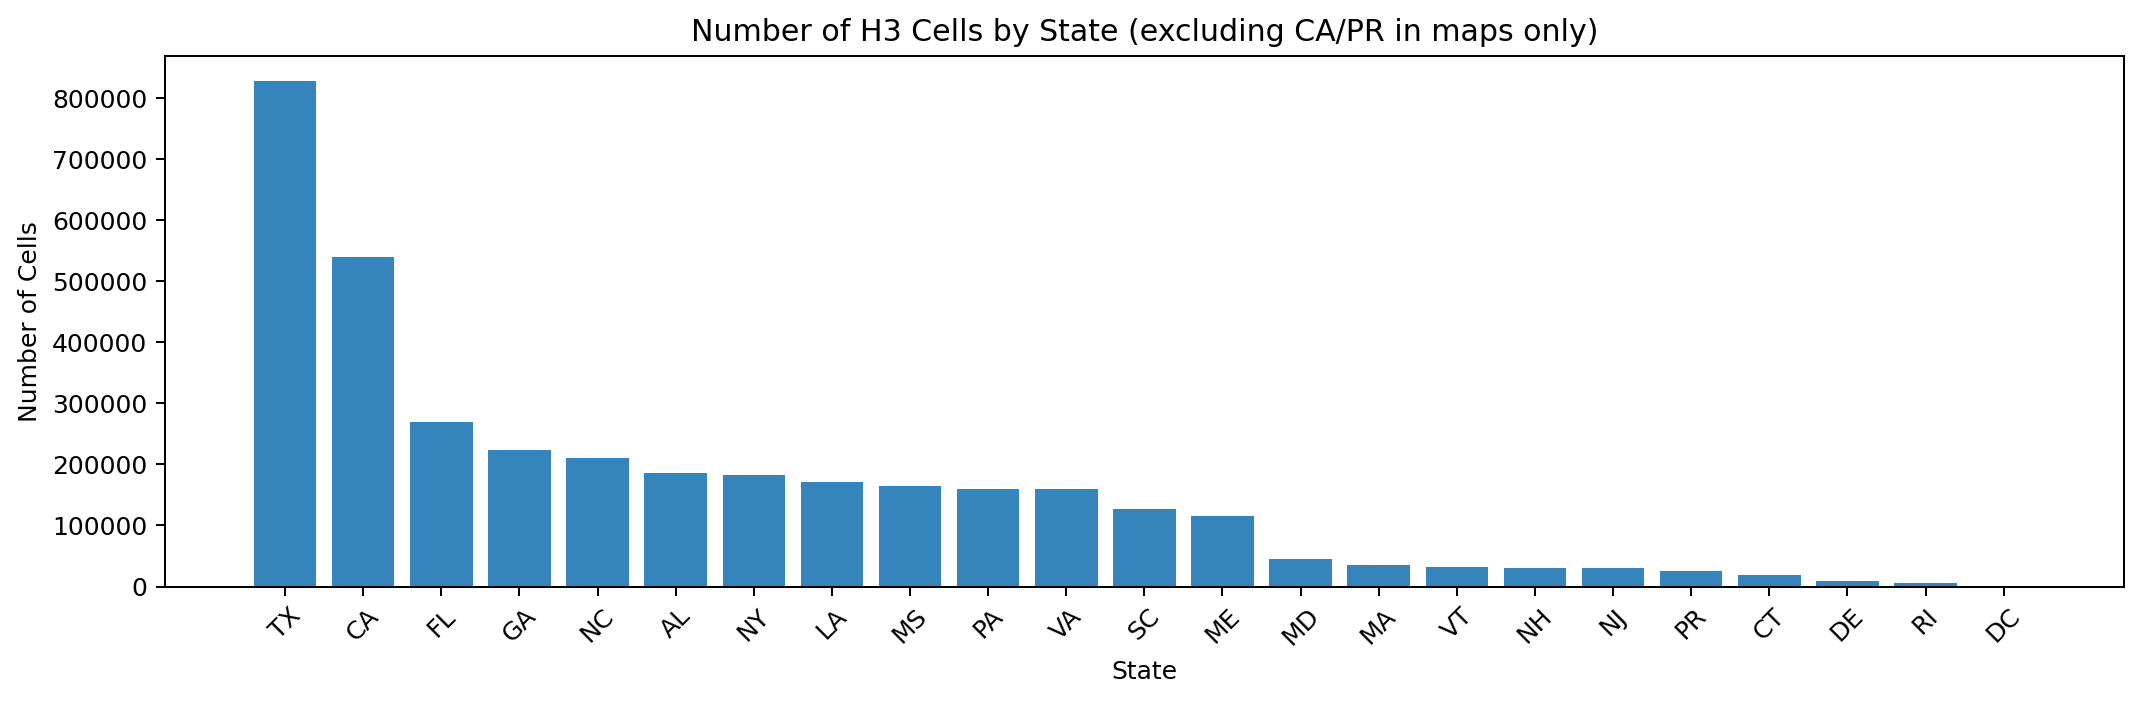

In [47]:
state_counts_plot =state_summary .copy ()

fig ,ax =plt .subplots (figsize =(12 ,4 ),dpi =180 )
ax .bar (state_counts_plot ['state_abbr'],state_counts_plot ['num_cells'],color ='#1f77b4',alpha =0.9 )
ax .set_title ('Number of H3 Cells by State (excluding CA/PR in maps only)')
ax .set_xlabel ('State')
ax .set_ylabel ('Number of Cells')
ax .tick_params (axis ='x',labelrotation =45 )
plt .tight_layout ()
plt .show ()
